# Fase 2 - Modelo base: regresión logística
## Pregunta B: Optimización de captación para universidades privadas
### Dataset: EILU_GRAD_2019 | Variable objetivo: SIT_PRO

**Pregunta de investigación:** ¿Qué perfil de estudiante de grado (según rama, tipo de universidad, origen socioeconómico, movilidad y sexo) se asocia con cada uno de los cuatro destinos profesionales principales?

**Variable objetivo:** `SIT_PRO` reagrupada en 4 categorías:
- `Becario_SinEmpleo`: SIT_PRO vacío o valor 1
- `Asalariado_Indefinido`: SIT_PRO = 2
- `Asalariado_Temporal`: SIT_PRO = 3
- `Autonomo_Empresario`: SIT_PRO ∈ {4, 5, 6}

---

## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from statsmodels.formula.api import mnlogit

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 2. Carga

In [2]:
DATA_PATH = '../data/raw/EILU_GRAD_2019.csv'
df_raw = pd.read_csv(DATA_PATH, sep='\t', encoding='latin-1', dtype=str, low_memory=False)
print(f'Registros: {df_raw.shape[0]:,} | Variables: {df_raw.shape[1]}')

Registros: 31,651 | Variables: 299


In [15]:
# Mapa de etiquetas del target 
TARGET_MAP = {
    '': 'Becario_SinEmpleo',
    '1': 'Becario_SinEmpleo',
    '2': 'Asalariado_Indefinido',
    '3': 'Asalariado_Temporal',
    '4': 'Autonomo_Empresario',
    '5': 'Autonomo_Empresario',
    '6': 'Autonomo_Empresario',
}

FEATURES   = ['SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN']
TARGET_RAW = 'SIT_PRO'

df = df_raw[FEATURES + [TARGET_RAW]].copy()

# Normalizar y mapear el target de forma vectorizada
df['TARGET'] = (
    df[TARGET_RAW]
    .fillna('')
    .str.strip()
    .apply(lambda v: TARGET_MAP.get(v.split('.')[0], np.nan))   
)
df = df.dropna(subset=['TARGET'])

print('Distribución del target:')
dist = df['TARGET'].value_counts()
print(dist)
print(f'\nBalance (%):')
print((dist / dist.sum() * 100).round(1))

Distribución del target:
TARGET
Asalariado_Indefinido    15558
Asalariado_Temporal       7572
Becario_SinEmpleo         6035
Autonomo_Empresario       2486
Name: count, dtype: int64

Balance (%):
TARGET
Asalariado_Indefinido    49.2
Asalariado_Temporal      23.9
Becario_SinEmpleo        19.1
Autonomo_Empresario       7.9
Name: count, dtype: float64


## 3. Preprocesado

In [16]:
#  Conversión numérica 
for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# UNIV_TIPO: binaria pública vs privada (NaN si código desconocido)
df['UNIV_TIPO'] = df['T_UNIV'].map({1: 'Publica', 2: 'Publica', 3: 'Privada', 4: 'Privada'})

# ESTUDIOS_PADRE / MADRE: valor 9 = NS/NC → NaN
df[['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']] = (
    df[['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']].replace(9, np.nan)
)

print('Nulos por variable (ANTES de imputar):')
feature_cols = ['SEXO', 'RAMA', 'UNIV_TIPO', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN']
print(df[feature_cols].isnull().sum())
print(f'\nTotal registros válidos: {len(df):,}')

Nulos por variable (ANTES de imputar):
SEXO                 0
RAMA                 0
UNIV_TIPO            0
ESTUDIOS_PADRE    2200
ESTUDIOS_MADRE    1467
MOV_IN              21
dtype: int64

Total registros válidos: 31,651


In [17]:
#  Split train/test

FEATURE_COLS = ['SEXO', 'RAMA', 'UNIV_TIPO', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN']

X = df[FEATURE_COLS].copy()
y = df['TARGET'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print('\nDistribución en train:')
print((y_train.value_counts(normalize=True) * 100).round(1))

Train: 25,320 | Test: 6,331

Distribución en train:
TARGET
Asalariado_Indefinido    49.2
Asalariado_Temporal      23.9
Becario_SinEmpleo        19.1
Autonomo_Empresario       7.9
Name: proportion, dtype: float64


In [18]:
# Columnas por tipo semántico
ordinal_cols = ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']   
binary_cols  = ['SEXO', 'MOV_IN']                     
numeric_cols = ['RAMA']                                
nominal_cols = ['UNIV_TIPO']                           

#  Preprocessor con imputación 
preprocessor = ColumnTransformer(
    transformers=[
        # Ordinales: imputar con la mediana + OrdinalEncoder
        ('ord',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
         ]),
         ordinal_cols),

        # Binarias y numéricas: imputar con moda
        ('num',
         SimpleImputer(strategy='most_frequent'),
         binary_cols + numeric_cols),

        # Nominal: imputar con moda + OneHotEncoder
        ('ohe',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
         ]),
         nominal_cols),
    ],
    remainder='drop'
)

print('Preprocessor definido con imputación explícita')

Preprocessor definido con imputación explícita


## 4. Modelo dummy

In [20]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test))
print(f'Accuracy dummy: {acc_dummy:.4f}')

Accuracy dummy: 0.4915


## 5. Regresión logística multinomial
### Por qué `class_weight='balanced'`
El dataset tiene un desbalanceo estructural pronunciado: `Asalariado_Indefinido` representa ~50% y `Autonomo_Empresario` ~5%. 

### Por qué `saga` en lugar de `lbfgs`
`saga` soporta penalización L1 y ElasticNet (útil para selección de variables), escala mejor en datasets grandes, y converge de forma equiparable a `lbfgs` en este tipo de problemas.

In [21]:
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        multi_class='multinomial',
        solver='saga',          
        penalty='l2',
        max_iter=1000,          
        C=0.5,                  
        class_weight='balanced',
        tol=1e-4,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

pipe_lr.fit(X_train, y_train)
print('Modelo entrenado')

Modelo entrenado


## 6. Evaluación completa

In [23]:
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
auc_lr = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', average='macro')

print(f'Accuracy:  {acc_lr:.4f}  (Dummy: {acc_dummy:.4f})')
print(f'F1-macro:  {f1_lr:.4f}   métrica principal (clases desbalanceadas)')
print(f'AUC-macro: {auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr))

Accuracy:  0.2384  (Dummy: 0.4915)
F1-macro:  0.2374   métrica principal (clases desbalanceadas)
AUC-macro: 0.5817

                       precision    recall  f1-score   support

Asalariado_Indefinido       0.57      0.09      0.16      3112
  Asalariado_Temporal       0.28      0.36      0.31      1515
  Autonomo_Empresario       0.11      0.46      0.18       497
    Becario_SinEmpleo       0.25      0.38      0.30      1207

             accuracy                           0.24      6331
            macro avg       0.30      0.32      0.24      6331
         weighted avg       0.41      0.24      0.22      6331



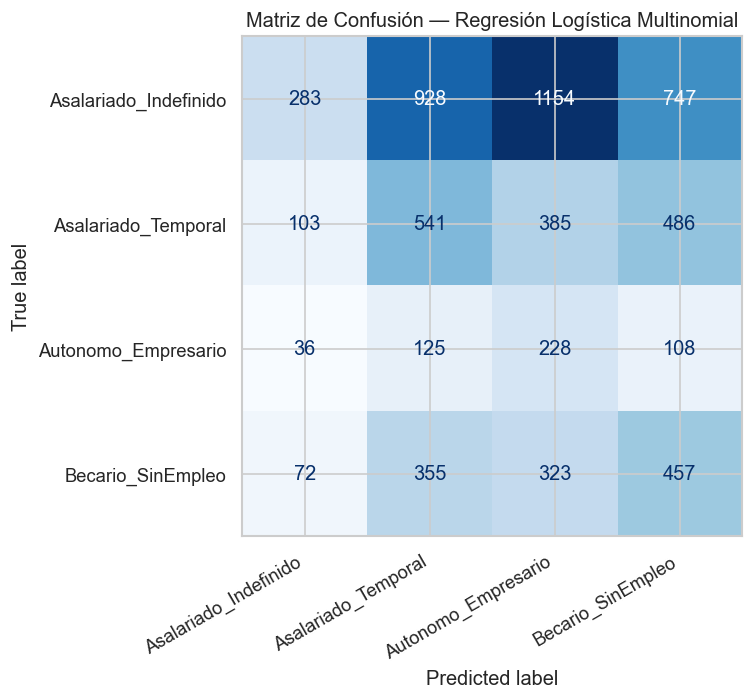

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_lr, labels=pipe_lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe_lr.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística Multinomial', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/11_matriz_confusion.png', bbox_inches='tight')
plt.show()

## 7. Validación cruzada estratificada

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr'   
}

cv_scores = cross_validate(
    pipe_lr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print('Validación cruzada k=5 - Regresión logística:')
print(f"  Accuracy:  {cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}")
print(f"  F1-macro:  {cv_scores['test_f1_macro'].mean():.4f} ± {cv_scores['test_f1_macro'].std():.4f}")
print(f"  AUC-OVR:   {cv_scores['test_roc_auc_ovr'].mean():.4f} ± {cv_scores['test_roc_auc_ovr'].std():.4f}")

Validación cruzada k=5 — Regresión Logística:
  Accuracy:  0.2399 ± 0.0053
  F1-macro:  0.2385 ± 0.0047
  AUC-OVR:   0.5836 ± 0.0027


## 8. Interpretación estadística con statsmodels

In [27]:
# Preparación del dataframe para statsmodels
le_sm = LabelEncoder()
df_sm = df[FEATURE_COLS + ['TARGET']].copy()

# Imputar con moda en train
for col in ordinal_cols + binary_cols + numeric_cols:
    df_sm[col] = df_sm[col].fillna(df_sm[col].mode()[0])
df_sm['UNIV_TIPO'] = df_sm['UNIV_TIPO'].fillna(df_sm['UNIV_TIPO'].mode()[0])

df_sm['UNIV_PRIV'] = (df_sm['UNIV_TIPO'] == 'Privada').astype(int)
df_sm['TARGET_CODE'] = le_sm.fit_transform(df_sm['TARGET'])
df_sm['RAMA']   = df_sm['RAMA'].astype(int)
df_sm['SEXO']   = df_sm['SEXO'].astype(int)
df_sm['MOV_IN'] = df_sm['MOV_IN'].astype(int)

formula = 'TARGET_CODE ~ SEXO + RAMA + UNIV_PRIV + ESTUDIOS_PADRE + ESTUDIOS_MADRE + MOV_IN'
model_sm = mnlogit(formula, data=df_sm).fit(maxiter=300, disp=False)

print('Clases codificadas:', dict(enumerate(le_sm.classes_)))
print()
print(model_sm.summary())

Clases codificadas: {0: 'Asalariado_Indefinido', 1: 'Asalariado_Temporal', 2: 'Autonomo_Empresario', 3: 'Becario_SinEmpleo'}

                          MNLogit Regression Results                          
Dep. Variable:            TARGET_CODE   No. Observations:                31651
Model:                        MNLogit   Df Residuals:                    31630
Method:                           MLE   Df Model:                           18
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                 0.01625
Time:                        14:24:05   Log-Likelihood:                -37584.
converged:                       True   LL-Null:                       -38205.
Covariance Type:            nonrobust   LLR p-value:                1.264e-252
 TARGET_CODE=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.9784      0.092    -10.599      0.000      -1.159      

In [29]:
# Odds Ratios con intervalos de confianza

params = model_sm.params
conf   = model_sm.conf_int()
pvals  = model_sm.pvalues

print('ODDS RATIOS por ecuación')

for eq in params.columns:

    coef = params[eq]

    
    ci = conf.loc[:, eq] if isinstance(conf.columns, pd.MultiIndex) else conf


    if isinstance(conf.columns, pd.MultiIndex):
        ci_lower = ci.xs('lower', level=1, axis=1)
        ci_upper = ci.xs('upper', level=1, axis=1)
    else:
        ci_lower = ci.iloc[:, 0]
        ci_upper = ci.iloc[:, 1]

    or_df = pd.DataFrame({
        'OR': np.exp(coef),
        'CI 2.5%': np.exp(ci_lower),
        'CI 97.5%': np.exp(ci_upper),
        'p-value': pvals[eq],
        'sig': pvals[eq].apply(
            lambda p: '***' if p < 0.001 else
                      '**'  if p < 0.01 else
                      '*'   if p < 0.05 else ''
        )
    }, index=params.index)

    print(f'\n→ Ecuación vs clase 0 ({le_sm.classes_[0]}):')
    print(or_df.round(3).to_string())

ODDS RATIOS por ecuación

→ Ecuación vs clase 0 (Asalariado_Indefinido):
                   OR  CI 2.5%  CI 97.5%  p-value  sig
Intercept       0.376      NaN       NaN    0.000  ***
SEXO            1.620      NaN       NaN    0.000  ***
RAMA            0.955      NaN       NaN    0.000  ***
UNIV_PRIV       0.796      NaN       NaN    0.000  ***
ESTUDIOS_PADRE  0.976      NaN       NaN    0.003   **
ESTUDIOS_MADRE  1.028      NaN       NaN    0.001  ***
MOV_IN          0.818      NaN       NaN    0.000  ***

→ Ecuación vs clase 0 (Asalariado_Indefinido):
                   OR  CI 2.5%  CI 97.5%  p-value  sig
Intercept       0.098      NaN       NaN    0.000  ***
SEXO            0.776      NaN       NaN    0.000  ***
RAMA            1.052      NaN       NaN    0.012    *
UNIV_PRIV       1.258      NaN       NaN    0.000  ***
ESTUDIOS_PADRE  1.016      NaN       NaN    0.207     
ESTUDIOS_MADRE  1.028      NaN       NaN    0.035    *
MOV_IN          1.264      NaN       NaN    0.000  ***

## 9. Exploración de la interacción T_UNIV × RAMA

La V de Cramér de `T_UNIV` con el target es débil (~0.067), posiblemente porque su efecto varía por rama: privada en Salud o Ingeniería puede tener efecto muy diferente que en Artes.

In [30]:
df_inter = df_sm.copy()
df_inter['TUNIV_X_RAMA'] = df_inter['UNIV_PRIV'] * df_inter['RAMA']

formula_inter = ('TARGET_CODE ~ SEXO + RAMA + UNIV_PRIV + '
                 'ESTUDIOS_PADRE + ESTUDIOS_MADRE + MOV_IN + TUNIV_X_RAMA')
model_inter = mnlogit(formula_inter, data=df_inter.dropna()).fit(maxiter=300, disp=False)

print('Coeficientes de TUNIV_X_RAMA:')
for eq in model_inter.params.columns:
    coef = model_inter.params.loc['TUNIV_X_RAMA', eq]
    pval = model_inter.pvalues.loc['TUNIV_X_RAMA', eq]
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f'  Ecuación {eq}: coef={coef:.4f}  p={pval:.4f}  {sig}')

# LRT: ¿mejora significativamente el modelo con la interacción?
from scipy import stats
lrt_stat = -2 * (model_sm.llf - model_inter.llf)
df_diff  = model_inter.df_model - model_sm.df_model
lrt_p    = 1 - stats.chi2.cdf(lrt_stat, df=df_diff)
print(f'\n Ratio Test (interacción): χ²={lrt_stat:.2f}, df={df_diff:.0f}, p={lrt_p:.4f}')

Coeficientes de TUNIV_X_RAMA:
  Ecuación 0: coef=0.2687  p=0.0000  ***
  Ecuación 1: coef=0.3776  p=0.0000  ***
  Ecuación 2: coef=0.2011  p=0.0001  ***

 Ratio Test (interacción): χ²=73.62, df=3, p=0.0000


## 10. Discusión y limitaciones del modelo base

**Decisiones clave:**
- `class_weight='balanced'` para evitar que Asalariado_Indefinido (~50%) domine la optimización.
- Pipeline con `SimpleImputer` ajustado solo en train.
- `solver='saga'` para mayor flexibilidad y escalabilidad.
- F1-macro como métrica principal (equitativamente sensible a las 4 clases).

**Limitaciones:**
1. `RAMA` se trata como numérica cuando es nominal ordinal → los modelos no lineales lo capturarán mejor.
2. La clase `Autonomo_Empresario` (~5%) sigue siendo difícil de recuperar; se explorará SMOTE en Fase 3.